In [90]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [195]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')

In [92]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [93]:
len(df)

9704

In [94]:
# Preparing the dataset

In [95]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']

In [96]:
df_base = df[base]

In [97]:
df_base.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


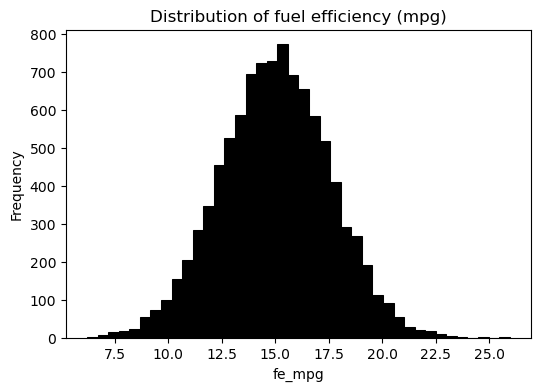

In [98]:
plt.figure(figsize=(6, 4))

sns.histplot(df_base.fuel_efficiency_mpg, bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('fe_mpg')
plt.title('Distribution of fuel efficiency (mpg)')

plt.show()

In [99]:
## No long tail!

In [100]:
# Question 1

In [101]:
df_base.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [102]:
# Question 2

In [103]:
df_base['horsepower'].median()

149.0

In [104]:
# Prepare and split the dataset

In [196]:
np.random.seed(42)

n = len(df)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [197]:
y_train_orig = df_train.fuel_efficiency_mpg.values
y_val_orig = df_val.fuel_efficiency_mpg.values
y_test_orig = df_test.fuel_efficiency_mpg.values

y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [107]:
# Linear regression

In [198]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [109]:
# Question 3

In [110]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year']

In [199]:
def prepare_X(df, fill_num=0):
    df_num = df[base].copy()
    df_num = df_num.fillna(fill_num)
    X = df_num.values
    return X

In [200]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [113]:
# Get the mean value of horsepower which we'll need below
df_train['horsepower'].mean()

149.54476367006487

In [114]:
# Fill missing numbers with 0s

In [204]:
X_train = prepare_X(df_train,0)
w_0, w = train_linear_regression(X_train, y_train)

In [206]:
X_val = prepare_X(df_val,0)
y_pred = w_0 + X_val.dot(w)

In [207]:
score = rmse(y_val, y_pred)

In [208]:
score

0.03997925782347178

In [209]:
round(score, 2)

0.04

In [ ]:
# Fill missing munmbers with mean value of horsepower

In [141]:
X_train = prepare_X(dX_val = prepare_X(df_val,149.54)
w_0, w = train_linear_regression(X_train, y_train)

In [142]:
X_val = prepare_X(df_val,149.54)
y_pred = w_0 + X_val.dot(w)

In [143]:
score = rmse(y_val, y_pred)

In [145]:
score

0.037327695652107425

In [130]:
round(score, 2)

0.04

In [ ]:
# Question 4 

In [201]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [228]:
X_train = prepare_X(df_train, fill_num=0)
X_val = prepare_X(df_val, fill_num=0)

results = []
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    results.append((r, score))
    print(f'{r:6.2f}   {round(score, 2):.2f}   (actual: {score:.6f})')

print()
print("Best r value:")
best_r, best_rmse = min(results, key=lambda x: x[1])
print(f"r = {best_r} with RMSE = {round(best_rmse, 2)}")


  0.00   0.17   (actual: 0.171922)
  0.01   0.17   (actual: 0.171939)
  0.10   0.17   (actual: 0.172060)
  1.00   0.17   (actual: 0.172198)
  5.00   0.17   (actual: 0.172221)
 10.00   0.17   (actual: 0.172224)
100.00   0.17   (actual: 0.172227)

Best r value:
r = 0 with RMSE = 0.17


In [ ]:
# Question 5

In [214]:
scores = []
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)

    n = len(df)
    
    n_val = int(0.2 * n)
    n_test = int(0.2 * n)
    n_train = n - (n_val + n_test)
    
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_shuffled = df.iloc[idx]
    
    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test = df_shuffled.iloc[n_train+n_val:].copy()

    # Extract and transform target variables for THIS split
    y_train_seed = np.log1p(df_train.fuel_efficiency_mpg.values)
    y_val_seed = np.log1p(df_val.fuel_efficiency_mpg.values)
    
    # Remove target from feature dataframes
    df_train_features = df_train.drop('fuel_efficiency_mpg', axis=1)
    df_val_features = df_val.drop('fuel_efficiency_mpg', axis=1)
    
    # Prepare X and train
    X_train = prepare_X(df_train_features, 0)
    w_0, w = train_linear_regression(X_train, y_train_seed)  # Use new y_train_seed

    X_val = prepare_X(df_val_features, 0)
    y_pred = w_0 + X_val.dot(w)

    score = rmse(y_val_seed, y_pred)  # Use new y_val_seed
    scores.append(score)
    
    print(f"Seed {s}: RMSE = {score:.6f}")


Seed 0: RMSE = 0.038018
Seed 1: RMSE = 0.039279
Seed 2: RMSE = 0.039447
Seed 3: RMSE = 0.038728
Seed 4: RMSE = 0.037275
Seed 5: RMSE = 0.039384
Seed 6: RMSE = 0.038908
Seed 7: RMSE = 0.038380
Seed 8: RMSE = 0.040190
Seed 9: RMSE = 0.038608


In [215]:

print(round(np.std(scores),3))

0.001


In [216]:
# Question 6

In [227]:
np.random.seed(9)

n = len(df)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

y_train_seed = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val_seed = np.log1p(df_val.fuel_efficiency_mpg.values)

df_train_features = df_train.drop('fuel_efficiency_mpg', axis=1)
df_val_features = df_val.drop('fuel_efficiency_mpg', axis=1)

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
X_full_train = prepare_X(df_full_train)

y_full_train = np.concatenate([y_train, y_val])

w_0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test)
y_pred = w_0 + X_test.dot(w)

score = rmse(y_test, y_pred)

print(score)

0.15791143910577637
